# part 3

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)} #creating Lookup table ]
stoi['.'] = 0 #special character
itos = {i:s for s,i in stoi.items()} #integer to string mapping - inverse of stoi 
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset to get training, validation and test split
block_size = 3 #context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []
    for w in words:

        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '----->', itos[ix])
            context = context[1:] + [ix] #crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) #get test split
Xdev, Ydev = build_dataset(words[n1:n2]) # get dev/validation split
Xte, Yte = build_dataset(words[n1:]) #get test split

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([45521, 3]) torch.Size([45521])


In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),              generator=g) 
w1 = torch.randn((n_embd * block_size, n_hidden),   generator=g) * (5/3) / ((n_embd * block_size) ** 0.5) # 5/3 added for efficient init. using Kaiming initialization
b1 = torch.randn(n_hidden,                          generator=g) * 0.01 #not using bias cause we are using batch normalization layer after it
w2 = torch.randn((n_hidden, vocab_size),            generator=g) * 0.01 # 0.01 added for efficient init.
b2 = torch.randn(vocab_size,                        generator=g) * 0

bngain = torch.ones((1, n_hidden)) #batch normalization gain - parameter
bnbias = torch.zeros((1, n_hidden)) #batch normalization bias
bnmean_running = torch.zeros((1, n_hidden)) #batch norm mean running - buffer
bnstd_running = torch.ones((1, n_hidden))  #BN standard deviation running

parameters = [C, w1, b1, w2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) #number of parameters in the model

for p in parameters:
    p.requires_grad = True


12297


variance is standard deviation (std) square
hpreact.std(0, keepdim=True) is the standard deviation - the 0 means we are calculating the STD across the 0th dimension (column) - keepdim=True so we can easily broadcast
Batch normalization (bn) is used to control the statistics of activations in the neural net - basically makes it so they dont have much dead neurons
Batch normalization is also a regularizer because it cause jitters in the batch, making it hard for the neural net to overfit
BN is added after layers that has multiplication such as linear layer or convolutional layer
Diff btw a parameter and a buffer is that a buffer isnt trained using backpropagation,its usually trained using a manually coded update.

In [7]:
# same optimization step as previous file
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix], #batch X, Ym - [32, 3, 2]

    #Forward pass
    emb = C[Xb] #embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) #concatenate the vectors
    # Linear layer
    hpreact = embcat @ w1 + b1 #hidden layer(h) pre-activation  - (32x100) -linear layer
    # BatchNorm Layer
    # ---------------------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True) #batch normalization mean on the ith iteration
    bnstdi =  hpreact.std(0, keepdim=True) # batch norm standard deviation
    hpreact = bngain * (hpreact  -  bnmeani)/ (bnstdi + 1e-5) + bnbias #perform batch normalization
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    # -----------------------------------------------------------------------

    # Non-linearity
    h =  torch.tanh(hpreact) # hidden layer
    logits = h @  w2 + b2 # output layer - (32, 27)
    loss  =  F.cross_entropy(logits, Yb) #loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward() 

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: #print every 10k step
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3010
 120000/ 200000: 1.9837
 130000/ 200000: 2.4523
 140000/ 200000: 2.3839
 150000/ 200000: 2.1987
 160000/ 200000: 1.9733
 170000/ 200000: 1.8668
 180000/ 200000: 1.9973
 190000/ 200000: 1.8347


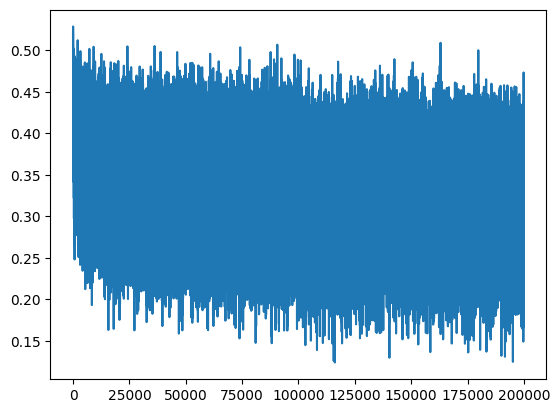

In [8]:
plt.plot(lossi)

In [9]:
# calibrate the batch norm at the end of training

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ w1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd  = hpreact.std(0, keepdim=True)

# this code block is not useful/needed because instead of us calculating the bnmean and bnstd after training, we are calculating it while training using bnmean_running and bnstd_running respectively and are getting similar result.

In [10]:
@torch.no_grad() # this decorator disales gradient tracking

def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) #concat into (N, block_size, n_embd)
    hpreact = embcat @ w1 #+ b1 # (N, n_hidden) - linear layer
    hpreact = bngain * (hpreact  -  bnmean_running)/ (bnstd_running +1e-5) + bnbias #perform batch normalization
    h =  torch.tanh(hpreact) #hidden layer
    logits = h @  w2 + b2 # output layer - (N, n_hidden)
    loss  =  F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')

split_loss('train')
split_loss('val')

train loss: 2.0666
val loss: 2.1052


In [11]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size #initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])] # (1,block_size,n_embd)
        h = torch.tanh(emb.view(1, -1) @ w1 + b1)
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)
        # sampling from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context  = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) #decode and print the generated word
        

briangmyazziyes.
bdulyah.
briyas.
brdrner.
sherkodrlithlyllsenleigh.
santhannchyziohmkrrnn.
shdumrishimnest.
jadestly.
prgbdulfuubdgghder.
jaquezmashburjahsis.
dashby.
sadya.
sus.
zakquslutel.
subristia.
sumprrdnn.
quloeonandphillsamreyxa.
hunton.
bdasirfalvinnwrllwildtalfr.
tandysestss.


In [ ]:
# lets train a deeper network

class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) /  fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__ (self, dim, eps=1e-5,  momentum=0.1):
        self.eps = eps
        self.momentum  = momentum
        self.training - True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

        def __call__(self, x):
            # calculate the forward pass
            if self.training:
                xmean = x.mean(0, keepdim=True) #batch mean
                xvar = x.var(0, keepdim=True) #batch variance
            else:
                xmean = self.running_mean
                xvar = self.running_var
            xhat = (x - xmean) / torch.sqrt(xvar + self.eps) #normalize the batch
            self.out = self.gamma * xhat + self.beta 
            # update the buffers
            if self.training:
                with torch.no_grad():
                    self.running_mean = (1-self.momentum) * self.running_mean + self.momentum * xmean
                    self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
            return self.out
        
    def parameters(self):
        return [self.gamma, self.beta]  
    
class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []
    
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden,), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden,), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden,), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden,), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden,), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size,) BatchNorm1d(vocab_size), 
]


with torch.no_grad():
    # last layer: make less confident
    # layers[-1].weight *= 0.1 # BatchNorm1d not in last layer
    layers[-1].gamma *= 0.1 #used gamma instead of weight because BatchNorm1d is in the last layer
    # other layers: make more confident
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) #number of parameters in the model
for p in parameters:
    p.requires_grad = True

46497


In [23]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix], #batch X, Y

    #Forward pass
    emb = C[Xb] 
    x = emb.view(emb.shape[0], -1) 
    for layer in layers:
        x  =   layer(x)
    loss  = F.cross_entropy(x, Yb) 
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad() #retain the gradients for all the intermediate outputs
    for p in parameters:
        p.grad = None
    loss.backward() 

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: #print every 10k step
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break # AFTER_DEBUG: would take out obvsiously to run full optimization


      0/ 200000: 3.2185


In [ ]:
# visualize the histogram   -  for the activation
plt.figure(figsize=(20,4)) #width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): #note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean().item(), t.std().item(), (t.abs()>0.97).float().mean().item()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1,].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

In [ ]:
# visualize the histogram - for the gradient
plt.figure(figsize=(20,4)) #width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): #note: exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1,].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation gradient distribution')

In [ ]:
# visualize the histogram 
plt.figure(figsize=(20,4)) #width and height of the plot
legends = []
for i,p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weigh %10s | mean %+f | std %e | grad:data ratio: %e' % (tuple(p.shape), t.mean(), t.std(), (t.std() / p.data.std()).item()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1,].detach(), hy.detach())
        legends.append(f'layer {i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights/parameters gradient distribution')

In [ ]:
plt.figure(figsize=(20,4))
legends = []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these rations should be -1e-3, indicateed on plot - the graphs shouldnt be far from the value or else we will be training too slow or too fast.
plt.legend(legends)

In [18]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1) #concat into (N, block_size, n_embd)
    for layer in layers:
        x = layer(x)
    loss  =  F.cross_entropy(x, y)
    print(f'{split} loss: {loss.item():.4f}')

In [19]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size #initialize with all ...
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])] # (1,block_size,n_embd)
        x = emb.view(emb.shape[0], -1) #concat the vectors
        for layer in layers:
            x = layer(x)
        logits = x
        probs = F.softmax(logits, dim=1)
        # sampling from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context  = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) #decode and print the generated word

erbuagmyazzhzevvndhfyalwqetvrsjejdrljg.
ozcjedgeliizsmpqppalekepxvqnpxarqeptzcmhvqrpcn.
szdbvrgxhgmjest.
jcjrwjkjqqxntpucfkubzmgvdtrxyqqufmehg.
kmejqvskkydmzhjl.
nagyybsufpzbjglvjurenjcrtvwsvevoecmpfhdxrfqnxoeobhggptixjsfcueywwkhmrjolbiilqiif.
evpkxwvlla.
odtabfsztkndgoizvsblitgfkxvbssivpu.
meewrkepxcmvyhxavttudkjgczekhgkgtipvtudt.
iwbddihzvorlq.
cjakepxugniagcrpppfmiipzjgvonxet.
jydnblkskfporygnogsvmwosfzpbsyknvmjcxtkncjbmu.
etew.
now.
copmrlxkgdcqbcep.
ccdfibsnipimhtecmosagouwzlrurdckappomtcokwxtnbnzkdphfam.
xcojfffuncxkhosy.
sj.
ascnpc.
cilwtanczhndtebimm.
